In [5]:
import pandas as pd


In [6]:
net = pd.read_csv("netflix_titles.csv")

In [7]:
net.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [8]:
print(net.info())
print(net.isnull().sum())
print(net.describe())

<class 'pandas.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   show_id       8807 non-null   str  
 1   type          8807 non-null   str  
 2   title         8807 non-null   str  
 3   director      6173 non-null   str  
 4   cast          7982 non-null   str  
 5   country       7976 non-null   str  
 6   date_added    8797 non-null   str  
 7   release_year  8807 non-null   int64
 8   rating        8803 non-null   str  
 9   duration      8804 non-null   str  
 10  listed_in     8807 non-null   str  
 11  description   8807 non-null   str  
dtypes: int64(1), str(11)
memory usage: 825.8 KB
None
show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64
       rele

In [9]:
poucentage =(net.isnull().sum() / 8807 ) * 100
print(poucentage)

show_id          0.000000
type             0.000000
title            0.000000
director        29.908028
cast             9.367549
country          9.435676
date_added       0.113546
release_year     0.000000
rating           0.045418
duration         0.034064
listed_in        0.000000
description      0.000000
dtype: float64


In [10]:
net['director'] = net['director'].fillna("Unknown")
net['cast'] = net['cast'].fillna("Unknown")
net['country'] = net['country'].fillna("Unknown")

In [11]:
net['date_added'] = net['date_added'].fillna(net['date_added'].mode()[0])
net['rating'] = net['rating'].fillna(net['rating'].mode()[0])
net['duration'] = net['duration'].fillna(net['duration'].mode()[0])

In [12]:
net.isnull().sum()

show_id         0
type            0
title           0
director        0
cast            0
country         0
date_added      0
release_year    0
rating          0
duration        0
listed_in       0
description     0
dtype: int64

In [13]:

net['date_added'] = net['date_added'].str.strip()

In [14]:
print(repr(net['date_added'][0]))

'September 25, 2021'


In [15]:
net['date_added'] =pd.to_datetime(net['date_added'])

In [16]:
net.info()

<class 'pandas.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   show_id       8807 non-null   str           
 1   type          8807 non-null   str           
 2   title         8807 non-null   str           
 3   director      8807 non-null   str           
 4   cast          8807 non-null   str           
 5   country       8807 non-null   str           
 6   date_added    8807 non-null   datetime64[us]
 7   release_year  8807 non-null   int64         
 8   rating        8807 non-null   str           
 9   duration      8807 non-null   str           
 10  listed_in     8807 non-null   str           
 11  description   8807 non-null   str           
dtypes: datetime64[us](1), int64(1), str(10)
memory usage: 825.8 KB


In [17]:
net['year_added'] = net['date_added'].dt.year
net['month_added'] = net['date_added'].dt.month

In [18]:
titles_per_year = net['year_added'].value_counts().sort_index()

In [19]:
print(titles_per_year)

year_added
2008       2
2009       2
2010       1
2011      13
2012       3
2013      11
2014      24
2015      82
2016     429
2017    1188
2018    1649
2019    2016
2020    1889
2021    1498
Name: count, dtype: int64


In [20]:
!pip install plotly

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [21]:
import plotly.express as px

In [22]:
net_yearly = net['year_added'].value_counts().reset_index()
net_yearly.columns = ['year_added', 'count']

# 3. Trier par ordre chronologique
net_yearly = net_yearly.sort_values(by='year_added')

In [23]:
# Graphique en ligne
fig = px.line(
    net_yearly, 
    x='year_added', 
    y='count',
    title="Évolution du nombre de titres ajoutés sur Netflix par année",
    labels={'year_added': "Année d'ajout", 'count': "Nombre de titres"},
    markers=True  # Ajoute des points identifiables sur la ligne
)

# Afficher le graphique dans Jupyter / VS Code
fig.show()

In [24]:
# Graphique en barres
fig_bar = px.bar(
    net_yearly, 
    x='year_added', 
    y='count',
    title="Nombre de titres ajoutés sur Netflix par année",
    labels={'year_added': "Année d'ajout", 'count': "Nombre de titres"},
    color='count',  # Ajoute un dégradé de couleur selon le nombre de titres
    color_continuous_scale='Viridis'
)

fig_bar.show()

In [25]:
fig.write_html("netflix_ajouts_par_annee.html")

In [26]:
import matplotlib.pyplot as plt

In [29]:
primary_country = (
    net["country"].fillna("Inconnu").apply(lambda x: x.split(",")[0].strip())
)
top10_countries = primary_country.value_counts().head(10)
print(top10_countries)

country
United States     3211
India             1008
Unknown            831
United Kingdom     628
Canada             271
Japan              259
France             212
South Korea        211
Spain              181
Mexico             134
Name: count, dtype: int64


C:\Users\admin\AppData\Local\Temp\ipykernel_15276\3717378318.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


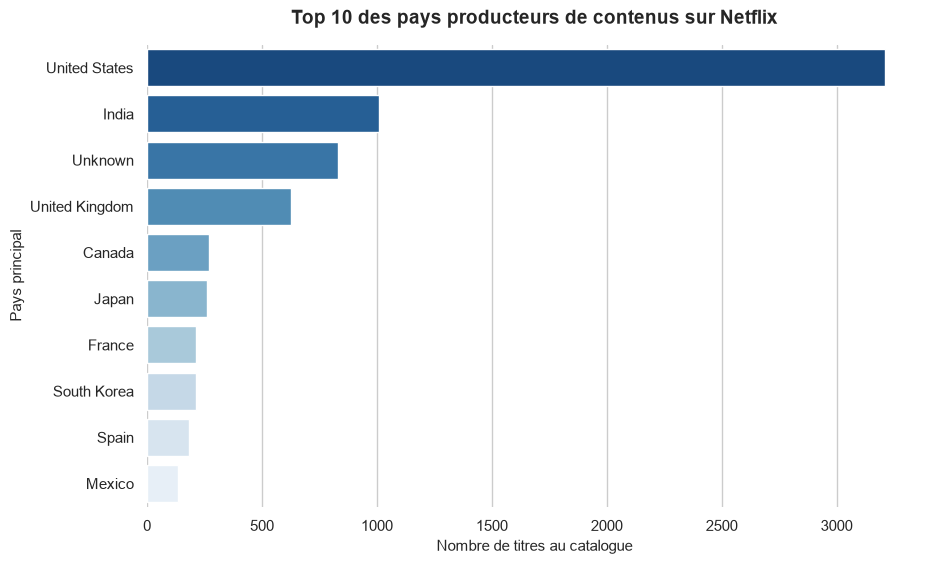

In [38]:
import seaborn as sns
plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid")

# Création du barplot horizontal
ax = sns.barplot(
    x=top10_countries.values,
    y=top10_countries.index,
    palette="Blues_r",  # Dégradé du plus foncé au plus clair
)

# Personnalisation & Lisibilité
plt.title(
    "Top 10 des pays producteurs de contenus sur Netflix",
    fontsize=14,
    pad=15,
    weight="bold",
)
plt.xlabel("Nombre de titres au catalogue", fontsize=11)
plt.ylabel("Pays principal", fontsize=11)

# Nettoyage des bordures inutiles (évite le chartjunk)
sns.despine(left=True, bottom=True)

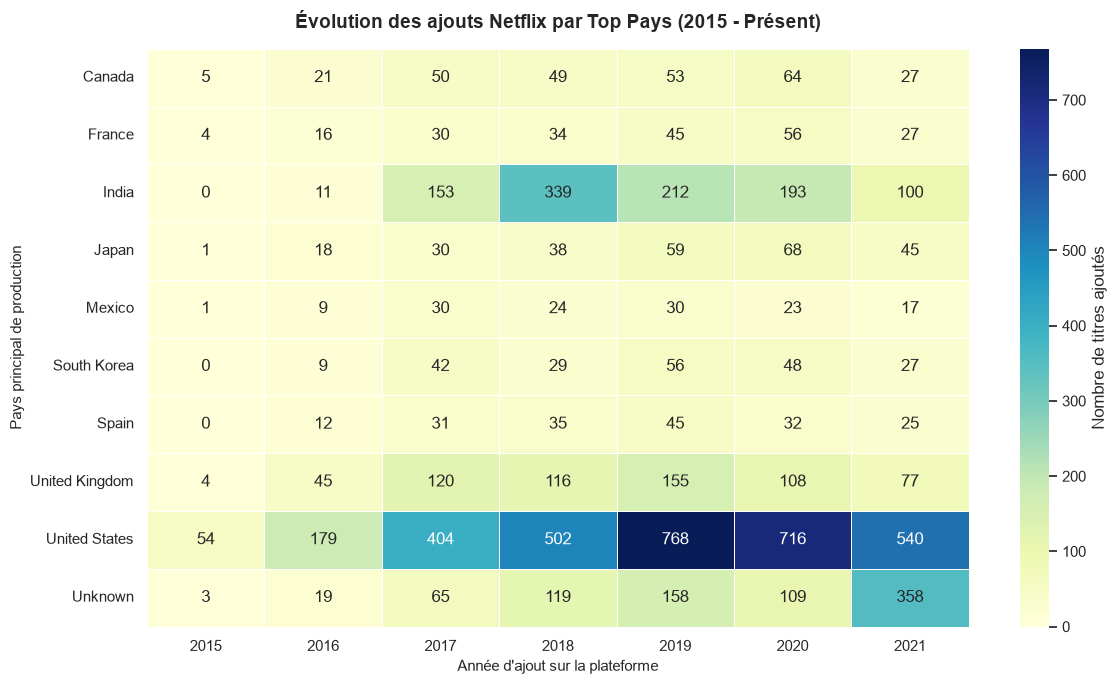

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# 1. Nettoyage : Extraction du premier pays principal
net["primary_country"] = (
    net["country"].fillna("Inconnu").apply(lambda x: x.split(",")[0].strip())
)

# 2. On isole les Top 10 pays identifiés à l'exercice 1
top_10_countries = net["primary_country"].value_counts().head(10).index
net_top10 = net[net["primary_country"].isin(top_10_countries)]

# 3. Filtrage des années (ex: à partir de 2015 pour éviter la zone creuse)
net_top10_recent = net_top10[net_top10["year_added"] >= 2015]

# 4. Table pivot (Pays en lignes, Années en colonnes)
pivot_table = pd.crosstab(
    index=net_top10_recent["primary_country"],
    columns=net_top10_recent["year_added"].astype(int),
)

# 5. Visualisation Heatmap
plt.figure(figsize=(12, 7))
sns.heatmap(
    pivot_table,
    cmap="YlGnBu",  # Palette séquentielle : clair = faible, foncé = fort
    annot=True,  # Affiche les valeurs numériques dans les cases
    fmt="d",  # Format nombre entier
    linewidths=0.5,  # Lignes de séparation légères
    cbar_kws={"label": "Nombre de titres ajoutés"},
)

# 6. Titre et axes clairs
plt.title(
    "Évolution des ajouts Netflix par Top Pays (2015 - Présent)",
    fontsize=14,
    pad=15,
    weight="bold",
)
plt.xlabel("Année d'ajout sur la plateforme", fontsize=11)
plt.ylabel("Pays principal de production", fontsize=11)

plt.tight_layout()
plt.show()

# Mini-rapport de conclusions — Projet Netflix

## Contexte
Suite du projet Titanic, cette fois sur le catalogue Netflix (`netflix_titles.csv`, 8 807 titres). Objectif : nettoyer les données et dégager des tendances par année et par pays.

## Méthodologie
1. Exploration initiale (`.head()`, `.info()`, `.describe()`) pour repérer les valeurs manquantes.
2. Colonnes très incomplètes (`director` ~30 %, `cast` et `country` ~9,4 %) imputées par `"Unknown"` ; colonnes peu incomplètes (`date_added`, `rating`, `duration`) imputées par leur mode.
3. `date_added` nettoyée et convertie en `datetime`, puis extraction de `year_added` et `month_added`.
4. Analyse temporelle : nombre de titres par année (courbe + barres, Plotly).
5. Analyse géographique : extraction du pays principal, top 10 des pays producteurs (Seaborn).
6. Croisement pays × année via table pivot et heatmap.

## Résultats clés
- **Données** : plus aucune valeur manquante après nettoyage (8 807 lignes complètes).
- **Croissance** : forte hausse des ajouts entre 2015 (82) et 2019 (2 016, pic), puis léger recul en 2020 (1 889) et 2021 (1 498, année incomplète).
- **Pays dominants** : États-Unis (3 211), Inde (1 008), puis Royaume-Uni, Canada, Japon, France, Corée du Sud, Espagne, Mexique. 831 titres en `Unknown` (pays manquant).
- **Heatmap pays/année** : croissance portée surtout par les États-Unis et l'Inde, avec une montée progressive d'autres pays (Corée du Sud, Japon) sur les années récentes.

## Conclusion
Le catalogue Netflix a connu une croissance rapide de 2015 à 2019 avant de ralentir en 2020-2021, avec une forte concentration géographique (États-Unis, Inde) mais une diversification internationale croissante. Le nettoyage par imputation a permis de conserver toutes les lignes sans fausser les tendances, la catégorie "Unknown" (~9 %) restant à interpréter avec prudence.